In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('dataset/StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [8]:
df.duplicated().sum()

0

unique value

In [9]:
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count < 10:
        print(f"\n🔹 {col} (Unique values: {unique_count})")
        print(df[col].value_counts())


🔹 Parental_Involvement (Unique values: 3)
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

🔹 Access_to_Resources (Unique values: 3)
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

🔹 Extracurricular_Activities (Unique values: 2)
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

🔹 Sleep_Hours (Unique values: 7)
Sleep_Hours
7     1741
8     1399
6     1376
9      775
5      695
10     312
4      309
Name: count, dtype: int64

🔹 Motivation_Level (Unique values: 3)
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

🔹 Internet_Access (Unique values: 2)
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

🔹 Tutoring_Sessions (Unique values: 9)
Tutoring_Sessions
1    2179
2    1649
0    1513
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

🔹 Family_Income (Unique values: 3)
Family_Income
Lo

eda

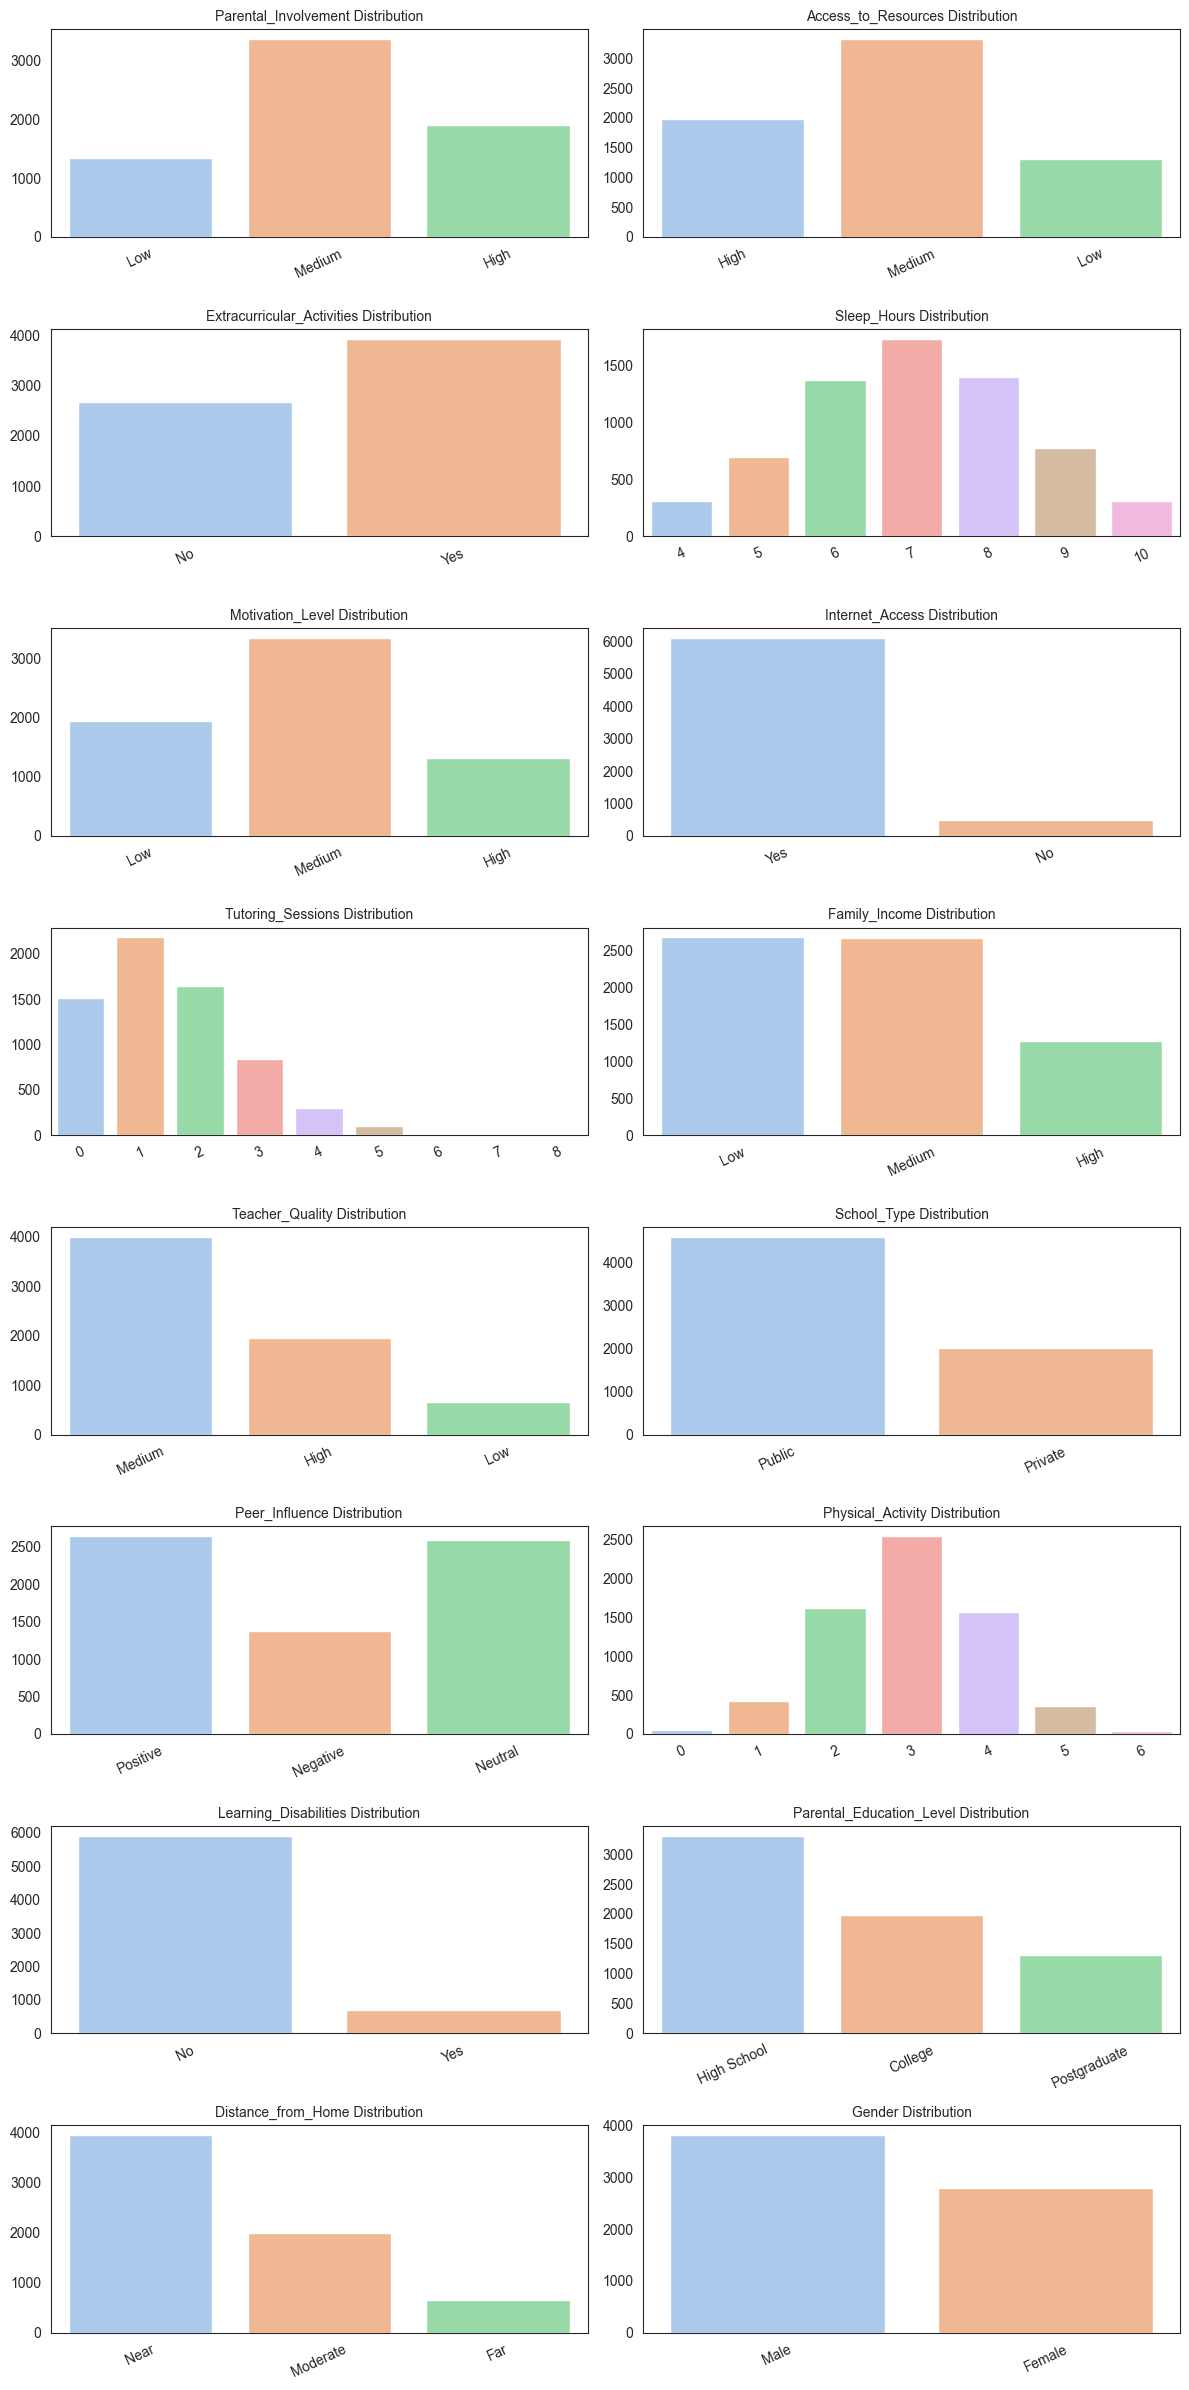

In [10]:
cols_for_count = ["Parental_Involvement","Access_to_Resources",
                  "Extracurricular_Activities","Sleep_Hours",
                  "Motivation_Level","Internet_Access","Tutoring_Sessions",
                  "Family_Income","Teacher_Quality","School_Type",
                  "Peer_Influence","Physical_Activity","Learning_Disabilities",
                 "Parental_Education_Level","Distance_from_Home","Gender",
                 ]

sns.set_style("white")
palette = sns.color_palette("pastel")

fig, axes = plt.subplots(8, 2, figsize=(12, 24))
axes = axes.flatten()

for i, col in enumerate(cols_for_count):
    sns.countplot(data=df, 
                  x=col, 
                  ax=axes[i], 
                  palette=palette
                 )
    axes[i].set_title(col+" Distribution", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', rotation=25)

for j in range(len(cols_for_count), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
numerical_cols = ["Hours_Studied","Attendance","Previous_Scores","Exam_Score"]

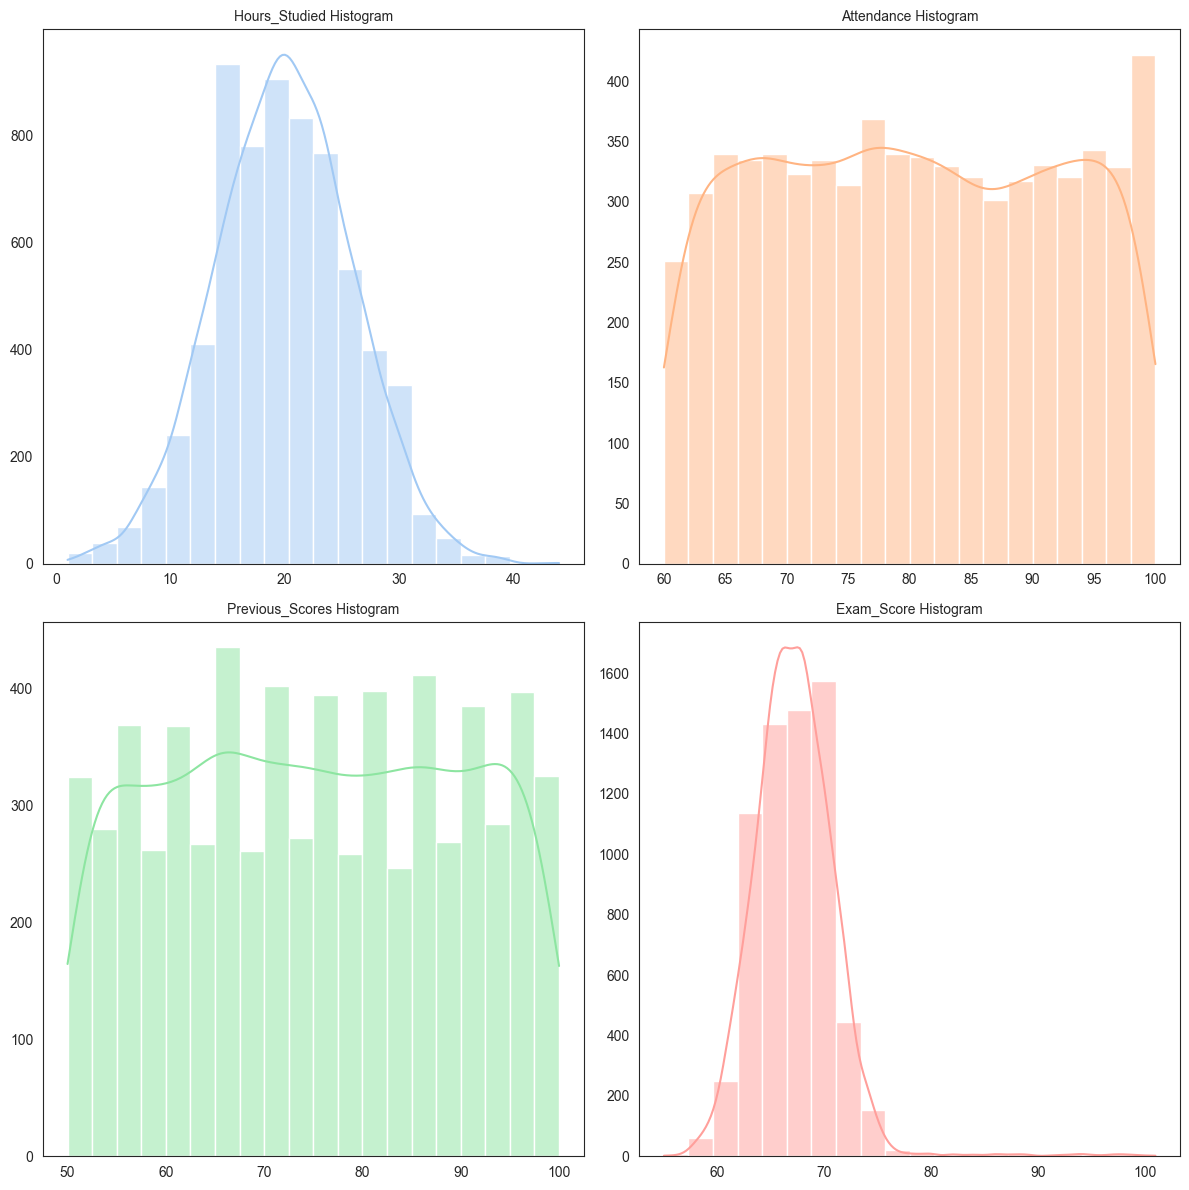

In [12]:
sns.set_style("white")
palette = sns.color_palette("pastel")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        color=palette[i % len(palette)],
        ax=axes[i]
        )
    axes[i].set_title(col+ " Histogram", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

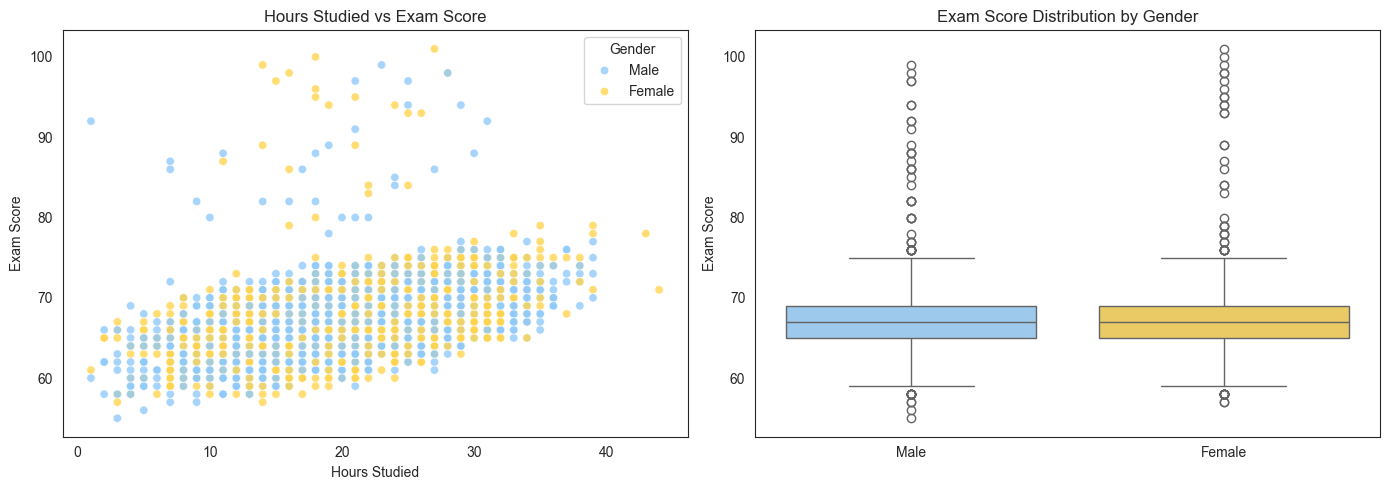

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    hue="Gender",
    palette=["#90CAF9", "#FFD54F"],
    alpha=0.8,
    data=df,
    ax=axes[0]
)
axes[0].set_title("Hours Studied vs Exam Score")
axes[0].set_xlabel("Hours Studied")
axes[0].set_ylabel("Exam Score")

sns.boxplot(
    x="Gender",
    y="Exam_Score",
    palette=["#90CAF9", "#FFD54F"],
    data=df,
    ax=axes[1]
)
axes[1].set_title("Exam Score Distribution by Gender")
axes[1].set_xlabel("")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

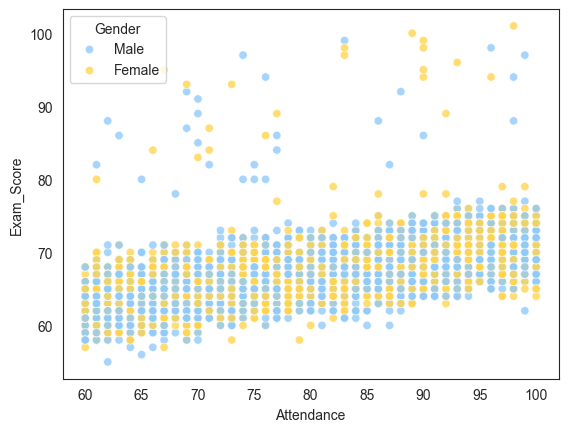

In [14]:
sns.scatterplot(
    x="Attendance",
    y="Exam_Score",
    hue="Gender",
    palette=["#90CAF9", "#FFD54F"],
    alpha=0.8,
    data=df
)
plt.show()

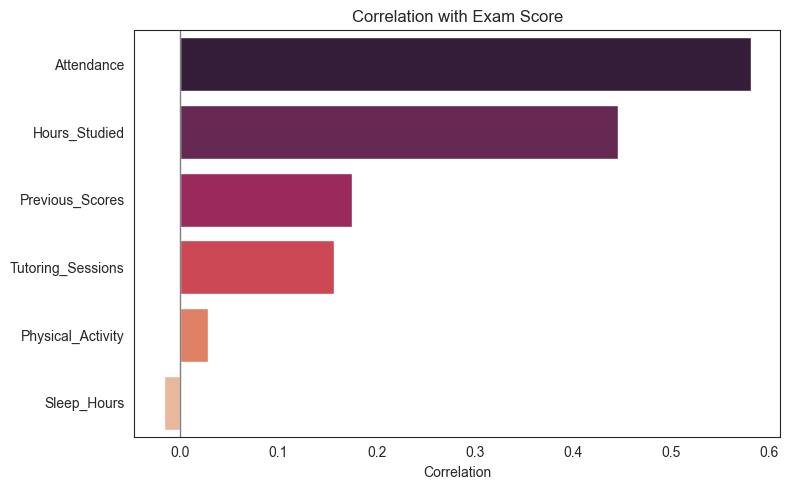

In [15]:
corr = (df.select_dtypes("number")
      .corr()["Exam_Score"]
      .drop("Exam_Score")
      .sort_values(ascending=False)
       )

plt.figure(figsize=(8, 5))

sns.barplot(
    x=corr.values,
    y=corr.index,
    palette="rocket")

plt.axvline(0, color="gray", linewidth=1)
plt.title("Correlation with Exam Score")
plt.xlabel("Correlation")
plt.ylabel("")

plt.tight_layout()
plt.show()

Preprocessing

In [16]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

In [17]:
num_cols = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions",
    "Physical_Activity"]

cat_cols = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"]

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ])

Modelling 

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ])

In [21]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Hours_Studied',
                                                   'Attendance',
                                                   'Previous_Scores',
                                                   'Sleep_Hours',
                                                   'Tutoring_Sessions',
                                                   'Physical_Activity']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Parental_Involvement',
                                                   'Access_to_Resources',
                                                   'Extracurricular_Activities',
                                                   'Motivation_Level',
                                                   'Internet_Access',
                                                   'Family_Income',
                                                   'Teacher_Quality',
                                                   'School_Type',
                                                   'Peer_Influence',
                                                   'Learning_Disabilities',
                                                   'Parental_Education_Level',
                                                   'Distance_from_Home',
                                                   'Gender'])])),
                ('model', LinearRegression())])

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = pipeline.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.3f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R²  : 0.770
MAE : 0.45
RMSE: 1.80


In [23]:
import joblib

# simpan pipeline
joblib.dump(pipeline, "model_1_tubesAIlab.pkl")

['model_1_tubesAIlab.pkl']